# 0/1 Knapsack

**Domain:** `data-structures-algorithms`

Imagine you're packing a backpack for a day hike. You've laid out everything
you'd *like* to bring &mdash; water, a first-aid kit, a camera, snacks, a
jacket &mdash; and each item has a **weight** (how much it adds to your pack)
and a **value** (how useful it is to you on the trail). Your backpack can
only hold so much weight before it's genuinely unsafe or unpleasant to
carry, so you have a strict **capacity**. You want the combination of items
that gives you the most total value without going over that weight limit.

Here's the catch: you can't bring "60% of the first-aid kit." Each item is
either fully in your pack or left at home &mdash; there's no cutting things
into fractions. That all-or-nothing constraint is exactly what the **"0/1"**
in "0/1 Knapsack" means: for every item, your decision variable is 0 (leave
it) or 1 (take it), nothing in between.

That's the whole problem:

> Given a set of items, each with a weight and a value, and a maximum total
> weight you can carry, choose the subset of items that **maximizes total
> value** without exceeding the weight limit.

By the end of this tutorial you'll be able to: explain why brute-force
checking every possible subset is hopeless at realistic sizes, build (by
hand and in code) the dynamic-programming table that solves it efficiently,
prove that table is correct by induction, explain the surprising
complexity-theory subtlety of *why* an "efficient" $O(nW)$ algorithm doesn't
contradict knapsack being NP-complete, and run a real, compiled C++
implementation that cross-checks its own answers against brute force and
measures its own runtime.

## The idea, intuitively

### Why not just try everything?

The most obvious approach: for every item, decide "take it" or "leave it,"
try **every possible combination**, throw out any combination that's too
heavy, and keep the most valuable one that fits.

The problem is how fast the number of combinations grows. With $n$ items,
each one independently either "in" or "out," the number of subsets is
$2^n$. That doubles with every single item you add:

| items ($n$) | subsets ($2^n$) |
|---:|---:|
| 10 | 1,024 |
| 20 | 1,048,576 |
| 30 | 1,073,741,824 |
| 50 | 1,125,899,906,842,624 |

**Thirty items &mdash; a completely realistic packing list &mdash; already
means checking over a billion subsets.** Fifty items is over a quadrillion.
No amount of "just make the computer faster" rescues brute force here; the
growth is exponential, not something a faster CPU meaningfully dents.

### The dynamic-programming idea

The key insight: many of those billion-plus subsets are wastefully
recomputing the same sub-decisions. **Dynamic programming (DP)** avoids
that by building up the answer to *smaller* versions of the problem first,
and reusing them.

Define a table `dp[i][w]` = **the best total value achievable using only
the first `i` items, with a weight capacity of `w`.** For each item, in
turn, there are only ever two choices:

- **Skip it** &mdash; the best value is whatever was achievable with the
  previous items at this same capacity.
- **Take it** (only possible if it fits) &mdash; the best value is this
  item's value plus the best value achievable with the *previous* items at
  the *reduced* capacity (capacity minus this item's weight).

`dp[i][w]` is just the better of those two options. Once you've filled in
the table for all `i` from 0 up to `n`, the answer to the whole problem is
sitting in `dp[n][W]`.

Let's make this concrete with a tiny example: 4 items, capacity 5.

| item | weight | value |
|---|---|---|
| 1 | 2 | 3 |
| 2 | 3 | 4 |
| 3 | 4 | 5 |
| 4 | 5 | 6 |

We'll build the table one row at a time. Row `dp[0]` (zero items available)
is all zeros &mdash; nothing to pick, nothing to gain. Here's the literal
recurrence applied by hand for the next two rows:

In [1]:
weights = [2, 3, 4, 5]
values  = [3, 4, 5, 6]
capacity = 5

# dp[0][w]: no items available at all -> nothing can be taken, value 0
# for every capacity.
dp0 = [0] * (capacity + 1)
print("dp[0] =", dp0)

# dp[1][w]: only item 1 (weight=2, value=3) is available.
dp1 = [0] * (capacity + 1)
for w in range(capacity + 1):
    if weights[0] > w:
        dp1[w] = dp0[w]                              # item 1 doesn't fit, skip it
    else:
        dp1[w] = max(dp0[w], dp0[w - weights[0]] + values[0])   # skip vs. take
print("dp[1] =", dp1)

# dp[2][w]: items 1 and 2 (item 2: weight=3, value=4) are available.
dp2 = [0] * (capacity + 1)
for w in range(capacity + 1):
    if weights[1] > w:
        dp2[w] = dp1[w]
    else:
        dp2[w] = max(dp1[w], dp1[w - weights[1]] + values[1])
print("dp[2] =", dp2)

print(f"\ndp[2][5] = {dp2[5]}")
print("That's the best value using only items 1-2 with capacity 5: take BOTH")
print("(weight 2+3 = 5, exactly at capacity; value 3+4 = 7).")

dp[0] = [0, 0, 0, 0, 0, 0]
dp[1] = [0, 0, 3, 3, 3, 3]
dp[2] = [0, 0, 3, 4, 4, 7]

dp[2][5] = 7
That's the best value using only items 1-2 with capacity 5: take BOTH
(weight 2+3 = 5, exactly at capacity; value 3+4 = 7).


Continuing that same by-hand process for items 3 and 4 fills out the whole
table:

| `dp[i][w]` | w=0 | w=1 | w=2 | w=3 | w=4 | w=5 |
|---|---|---|---|---|---|---|
| i=0 (no items) | 0 | 0 | 0 | 0 | 0 | 0 |
| i=1 (+item 1: w2,v3) | 0 | 0 | 3 | 3 | 3 | 3 |
| i=2 (+item 2: w3,v4) | 0 | 0 | 3 | 4 | 4 | **7** |
| i=3 (+item 3: w4,v5) | 0 | 0 | 3 | 4 | 5 | 7 |
| i=4 (+item 4: w5,v6) | 0 | 0 | 3 | 4 | 5 | 7 |

The final answer is `dp[4][5] = 7`, achieved back at row `i=2` and never
improved on afterward &mdash; items 3 and 4 simply don't help here, because
swapping either of them in forces something more valuable out. Tracing
which row first produced that 7 (and which cell it came from) tells you
*which items* were chosen, not just the best value &mdash; that's exactly
the **backtracking** step the C++ implementation performs later.

> **Takeaway:** the DP table doesn't check every subset. Each cell asks one
> tiny question &mdash; "given what I already know about smaller problems,
> is it better to skip this item or take it?" &mdash; and reuses already-
> solved smaller answers instead of recomputing them. That reuse is the
> entire reason it avoids the $2^n$ blowup.

## Going deeper: the formal definition

### The recurrence, precisely

Let there be $n$ items, item $i$ having weight $w_i$ and value $v_i$
($i = 1, \dots, n$), and a capacity $W$. Define:

$$
dp[i][w] = \text{the maximum total value achievable by choosing a subset of
items } \{1, \dots, i\} \text{ with total weight} \le w
$$

Then:

$$
dp[i][w] =
\begin{cases}
dp[i-1][w] & \text{if } w_i > w \quad \text{(item $i$ doesn't fit; can't take it)} \\[4pt]
\max\big(dp[i-1][w],\ dp[i-1][w - w_i] + v_i\big) & \text{otherwise (best of "skip" vs. "take")}
\end{cases}
$$

with base case $dp[0][w] = 0$ for all $w$ (no items available, so no value
possible).

### Correctness, by induction on $i$

**Claim:** for every $i \in \{0, \dots, n\}$ and every $w \in \{0, \dots,
W\}$, the value computed by the recurrence for $dp[i][w]$ equals the true
optimum $\text{OPT}(i, w)$ &mdash; the best value achievable choosing among
items $\{1, \dots, i\}$ with capacity $w$.

**Base case ($i=0$):** with zero items available, the only feasible subset
is the empty one, worth 0. $dp[0][w] = 0 = \text{OPT}(0, w)$ for all $w$.

**Inductive step:** assume $dp[i-1][w'] = \text{OPT}(i-1, w')$ for every
capacity $w'$ (the inductive hypothesis). Fix any capacity $w$. Any feasible
subset of items $\{1, \dots, i\}$ with weight $\le w$ falls into exactly one
of two cases:

- **It doesn't include item $i$.** Then it's a feasible subset of
  $\{1, \dots, i-1\}$ with weight $\le w$, so its value is at most
  $\text{OPT}(i-1, w)$, which by the IH equals $dp[i-1][w]$.
- **It includes item $i$** (only possible if $w_i \le w$). Removing item $i$
  leaves a feasible subset of $\{1, \dots, i-1\}$ with weight $\le w - w_i$,
  so the rest of the subset is worth at most $\text{OPT}(i-1, w - w_i)$, and
  by the IH that equals $dp[i-1][w - w_i]$. The whole subset is worth at
  most $dp[i-1][w - w_i] + v_i$.

Every feasible subset falls into one of these two cases, so
$\text{OPT}(i, w) = \max\big(dp[i-1][w],\ dp[i-1][w-w_i]+v_i\big)$ (when
$w_i \le w$; otherwise only the first case is possible) &mdash; which is
precisely the recurrence. Since both branches equal $dp[i][w]$ exactly, and
the recurrence takes their max, $dp[i][w] = \text{OPT}(i, w)$. $\blacksquare$

By induction, this holds for all $i$ up to $n$, so $dp[n][W]$ is the true
optimal value for the full problem.

### Complexity: $O(nW)$ time and space &mdash; and why that's "pseudo-polynomial"

The table has $(n+1)(W+1)$ cells, and each cell does $O(1)$ work (one
comparison, one addition, one max). That gives:

$$
\text{Time} = O(nW), \qquad \text{Space} = O(nW)
$$

At first glance $O(nW)$ looks like a perfectly ordinary polynomial-time
algorithm. **It is not, in the strict complexity-theory sense** &mdash; and
the reason is genuinely subtle, worth deriving carefully rather than just
asserting.

Computational complexity is measured **in terms of the size of the input as
written down** (its bit-length), not in terms of the numeric magnitudes the
input happens to encode. The input to knapsack includes the number $W$
itself, but writing $W$ down in binary only takes

$$
L = \lceil \log_2(W+1) \rceil \ \text{bits}
$$

So $W = O(2^L)$ &mdash; $W$ is *exponential* in its own bit-length $L$.
Substituting into the runtime:

$$
O(nW) = O(n \cdot 2^L)
$$

**That's exponential in $L$, the actual size of $W$ as it appears in the
input.** The algorithm is polynomial in the *numeric value* of $W$, but
exponential in the *number of bits* needed to write $W$ down. That
distinction is exactly what "**pseudo-polynomial**" means: polynomial-
looking runtime, expressed in terms of the input's magnitude rather than
its encoded size.

This is why the pseudo-polynomial DP is **not a contradiction** of 0/1
knapsack being NP-complete: NP-completeness is a statement about runtime as
a function of input bit-length, and $O(n \cdot 2^L)$ genuinely is
exponential in $L$. If $W$ is given as a small number relative to $n$ (the
usual case in this tutorial's benchmarks, and in most real applications),
$O(nW)$ behaves practically fine. But if $W$ is specified as an enormous
number using very few bits &mdash; say a 60-bit integer near
$10^{18}$ &mdash; $nW$ becomes astronomically large while the *input itself*
barely grew in size. The benchmark later in this tutorial makes exactly
this blow-up visible with real timings, not just the argument above.

(A related bit of terminology, from Garey & Johnson: problems like knapsack
that admit a pseudo-polynomial algorithm are called **weakly** NP-complete.
**Strongly** NP-complete problems have no pseudo-polynomial algorithm at
all unless P = NP &mdash; knapsack's weak NP-completeness is *why* this DP
is possible in the first place.)

### The $O(W)$ space optimization

The full 2D table is useful for backtracking *which* items were chosen (see
the visuals below), but computing only the *optimal value* doesn't need to
keep every row: $dp[i][\cdot]$ only ever depends on the row directly above
it, $dp[i-1][\cdot]$. Collapse the table into a single 1D array `dp[w]`,
updated in place for each item:

```
for each item i (weight w_i, value v_i):
    for w from W down to w_i:
        dp[w] = max(dp[w], dp[w - w_i] + v_i)
```

**The reverse iteration (`W` down to `w_i`) is not a stylistic choice --
it's required for correctness.** `dp[w - w_i]` needs to hold *last item's*
value when it's read. Scanning `w` from high to low means every `w - w_i`
that's about to be read is still smaller than the current `w`, so it hasn't
been overwritten yet this pass. If you instead scanned low-to-high, by the
time you reached a larger `w`, `dp[w - w_i]` might already have been
updated *by this same item* earlier in the same pass &mdash; which would
let the algorithm silently count item $i$'s value twice, violating the
0/1 (take-it-at-most-once) constraint. (This reverse-order trick is exactly
how the unbounded/"can take multiples" variant of the problem is solved
instead: iterate `w` forward, and reusing an item on its own updated value
becomes the intended behavior, not a bug.)

This drops the space bound to $O(W)$, though the reconstructed *item list*
requires either the full 2D table (traded space for that information) or a
second pass. The C++ implementation below includes both: a 2D version for
backtracking/visualization, and the 1D version for the performance
benchmark.

## Visuals

We'll use the **real, compiled C++ implementation** (`src/knapsack.cpp`,
walked through fully in the Implementation section below) to generate every
number and image in this section &mdash; nothing here is simulated in
Python. We compile it now, using **static linking**, since that's needed to
generate the real DP table for the heatmap below.

> **Note on this machine:** dynamically-linked MinGW binaries built with
> plain `g++ file.cpp -o file.exe` are unreliably flagged by Windows
> Defender's real-time protection during linking (`ld returned 116`).
> Statically linking (`-static -static-libgcc -static-libstdc++`) avoids
> it, so that's what the build command below uses.

In [2]:
import subprocess, pathlib

src_dir = pathlib.Path("src")
exe_path = src_dir / "knapsack.exe"

compile_cmd = [
    "g++", "-O2", "-std=c++17",
    "-static", "-static-libgcc", "-static-libstdc++",
    str(src_dir / "knapsack.cpp"), "-o", str(exe_path),
]
result = subprocess.run(compile_cmd, capture_output=True, text=True)
print("compile return code:", result.returncode)
if result.returncode != 0:
    print(result.stderr)
assert result.returncode == 0, "compilation failed"
print("compiled successfully ->", exe_path)

compile return code: 0
compiled successfully -> src\knapsack.exe


In [3]:
def run_knapsack(weights, values, capacity, mode="all", want_table=False):
    # Run the real compiled knapsack binary, return a dict of parsed results.
    lines_in = [f"{len(weights)} {capacity}",
                " ".join(str(w) for w in weights),
                " ".join(str(v) for v in values)]
    args = [str(exe_path), mode] + (["table"] if want_table else [])
    proc = subprocess.run(args, input="\n".join(lines_in), capture_output=True, text=True)
    assert proc.returncode == 0, proc.stderr

    out = {"table": []}
    for line in proc.stdout.splitlines():
        if line.startswith("table:"):
            out["table"].append([int(x) for x in line[len("table:"):].split()])
        elif line.endswith("_items") or "_items:" in line:
            key, _, rest = line.partition(":")
            out[key] = [int(x) for x in rest.split()]
        elif line.startswith("2d_path:"):
            pairs = line[len("2d_path:"):].split()
            out["2d_path"] = [tuple(int(x) for x in p.split(",")) for p in pairs]
        elif line.startswith("2d_table_rows"):
            continue  # dimensions info only; the parsed "table" list already has them
        elif "=" in line:
            key, val = line.split("=", 1)
            out[key] = int(val)
    return out

# Moderate example for the heatmap: 8 items, capacity 50.
import random
random.seed(3)
demo_weights = [random.randint(3, 20) for _ in range(8)]
demo_values  = [random.randint(5, 40) for _ in range(8)]
demo_capacity = 50

demo = run_knapsack(demo_weights, demo_values, demo_capacity, mode="2d", want_table=True)
print("weights:", demo_weights)
print("values: ", demo_values)
print("capacity:", demo_capacity)
print("optimal value:", demo["2d_value"])
print("chosen items (0-indexed):", demo["2d_items"])
print(f"table shape: {len(demo['table'])} rows x {len(demo['table'][0])} cols")

weights: [10, 20, 7, 14, 18, 5, 3, 18]
values:  [21, 40, 19, 17, 35, 39, 40, 35]
capacity: 50
optimal value: 159
chosen items (0-indexed): [0, 1, 2, 5, 6]
table shape: 9 rows x 51 cols


### The DP table as a heatmap, with the optimal path traced

Below is the **actual computed `dp[i][w]` table** from the run above,
color-coded by value. Overlaid on top is the **real backtracking path**
&mdash; the sequence of cells the program walked backward from `dp[n][W]`
to reconstruct which items were taken, i.e. exactly the same logic
described in the space-optimization section above, just applied to the
full 2D table.

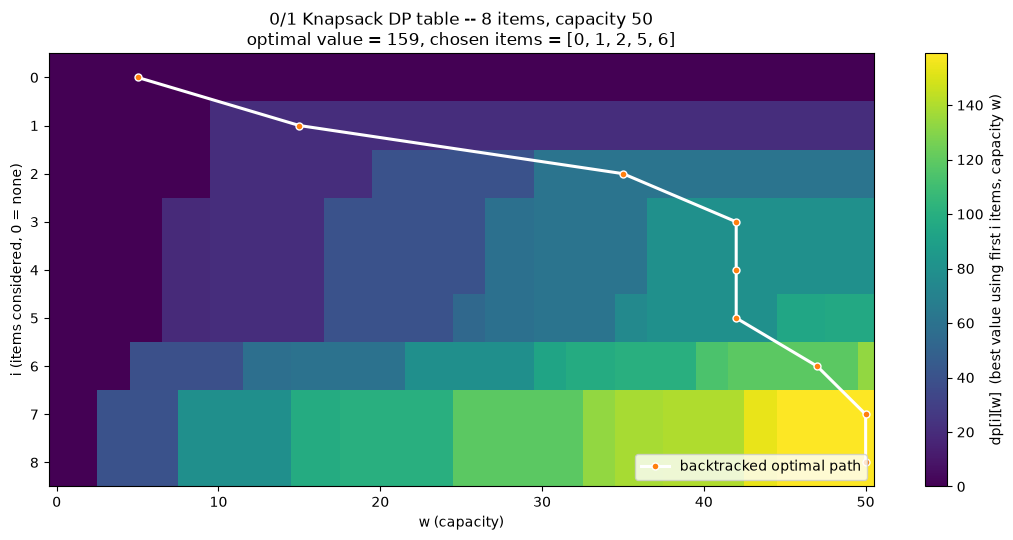

In [4]:
import matplotlib.pyplot as plt
import numpy as np

table = np.array(demo["table"])
path = demo["2d_path"]  # list of (i, w) tuples, in order from row 0 to row n

fig, ax = plt.subplots(figsize=(11, 5.5))
im = ax.imshow(table, aspect="auto", cmap="viridis", origin="upper")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("dp[i][w]  (best value using first i items, capacity w)")

path_i = [p[0] for p in path]
path_w = [p[1] for p in path]
ax.plot(path_w, path_i, color="white", linewidth=2.2, marker="o", markersize=5,
        markerfacecolor="#ff7f0e", markeredgecolor="white", label="backtracked optimal path")

ax.set_xlabel("w (capacity)")
ax.set_ylabel("i (items considered, 0 = none)")
ax.set_title(f"0/1 Knapsack DP table -- 8 items, capacity {demo_capacity}\n"
             f"optimal value = {demo['2d_value']}, chosen items = {demo['2d_items']}")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("dp_table_heatmap.png", dpi=110)
plt.show()

Reading the heatmap: value strictly **never decreases** moving down a
column (adding an item can only ever help or do nothing, never hurt &mdash;
that falls straight out of the $\max(\dots)$ in the recurrence). The
highlighted path shows exactly which rows the final answer's value actually
changed at: a **vertical** segment of the path (no leftward jump) means
that item was skipped at that row; a **diagonal jump left** by exactly
$w_i$ means that item was taken. Every diagonal jump in the path
corresponds to one of the item indices reported in `chosen items` above.

### Real benchmark: runtime vs. $n \times W$

The complexity derivation above claims $O(nW)$ time. Let's actually measure
it, using the real compiled 1D program across several $(n, W)$
combinations, including combinations with the **same product $nW$** split
different ways between $n$ and $W$ &mdash; if the $O(nW)$ bound is real,
those should take roughly the same time regardless of the split.

n=  5  W= 2,000,000  n*W=   10,000,000  time=  27,793 us
n= 10  W= 2,000,000  n*W=   20,000,000  time=  50,997 us
n= 20  W= 2,000,000  n*W=   40,000,000  time=  93,193 us


n= 40  W= 2,000,000  n*W=   80,000,000  time= 186,737 us


n= 40  W= 4,000,000  n*W=  160,000,000  time= 404,774 us


n= 80  W= 2,000,000  n*W=  160,000,000  time= 424,747 us


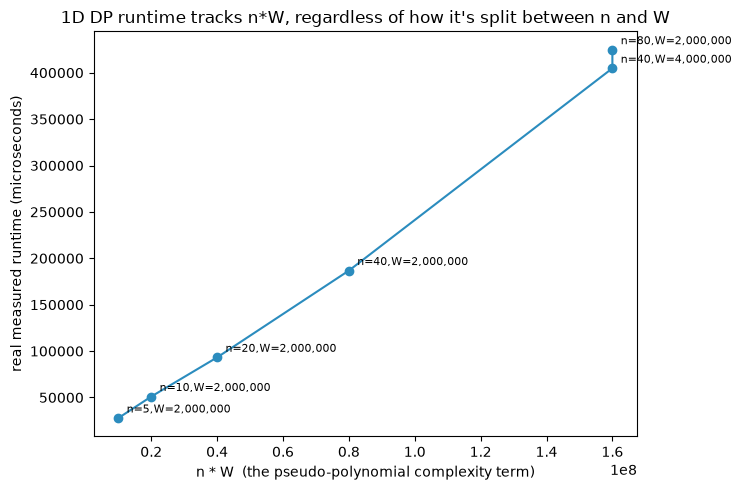

In [5]:
combos = [
    (5,  2_000_000),
    (10, 2_000_000),
    (20, 2_000_000),
    (40, 2_000_000),
    (40, 4_000_000),
    (80, 2_000_000),   # same n*W as the row above, different split
]

bench_results = []
for n, W in combos:
    random.seed(n * 1000 + W)
    w_list = [random.randint(1, max(2, W // 200)) for _ in range(n)]
    v_list = [random.randint(1, 1000) for _ in range(n)]
    res = run_knapsack(w_list, v_list, W, mode="1d")
    bench_results.append((n, W, n * W, res["1d_time_us"]))
    print(f"n={n:3d}  W={W:>10,d}  n*W={n*W:>13,d}  time={res['1d_time_us']:>8,d} us")

fig, ax = plt.subplots(figsize=(7.5, 5))
xs = [r[2] for r in bench_results]
ys = [r[3] for r in bench_results]
ax.plot(xs, ys, "o-", color="#2b8cbe")
for n, W, nw, t in bench_results:
    ax.annotate(f"n={n},W={W:,}", (nw, t), textcoords="offset points", xytext=(6, 4), fontsize=8)
ax.set_xlabel("n * W  (the pseudo-polynomial complexity term)")
ax.set_ylabel("real measured runtime (microseconds)")
ax.set_title("1D DP runtime tracks n*W, regardless of how it's split between n and W")
plt.tight_layout()
plt.savefig("runtime_vs_nW.png", dpi=110)
plt.show()

**Runtime scales with the product $n \times W$, not with $n$ or $W$
individually** &mdash; the two combinations with $nW = 160{,}000{,}000$
(`n=40, W=4,000,000` and `n=80, W=2,000,000`) take about the same real time
even though one has twice the items and half the capacity of the other.
That's the $O(nW)$ bound made visible, not just asserted.

### Making the pseudo-polynomial blow-up concrete

Now the point from "Going deeper": **fix $n$ and scale $W$ by orders of
magnitude.** The number of *bits* needed to encode $W$ barely grows (going
from $W=10^3$ to $W=10^7$ needs only about 13 more bits), but if runtime
really is driven by the numeric value of $W$ rather than its bit-length,
the real measured time should blow up by roughly the same $10{,}000\times$
factor.

W=     1,000  bits to encode W=10  time=       21 us
W=    10,000  bits to encode W=14  time=      201 us
W=   100,000  bits to encode W=17  time=    2,226 us
W= 1,000,000  bits to encode W=20  time=   33,046 us


W= 5,000,000  bits to encode W=23  time=  185,729 us


W=10,000,000  bits to encode W=24  time=  404,890 us


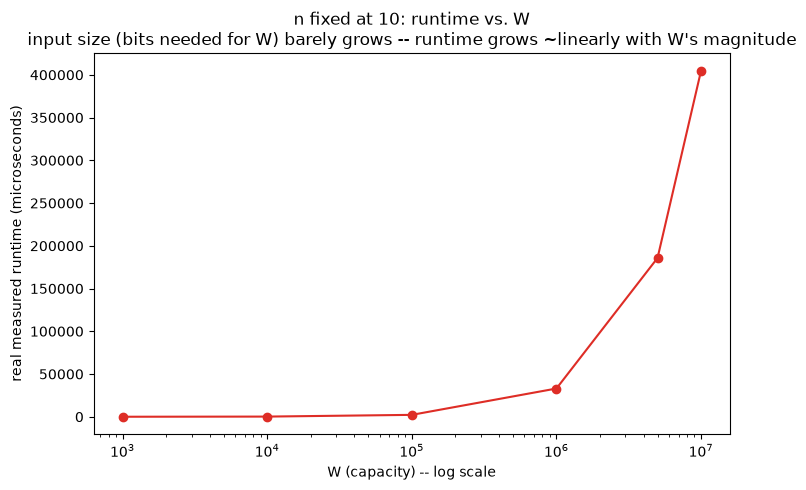


Bits needed to encode W grew from 10 to 24 (only 14 more bits).
Real measured runtime grew from 21 us to 404,890 us (~19280x).


In [6]:
fixed_n = 10
W_values = [1_000, 10_000, 100_000, 1_000_000, 5_000_000, 10_000_000]

blowup_results = []
for W in W_values:
    random.seed(fixed_n * 7 + W)
    w_list = [random.randint(1, max(2, W // 100)) for _ in range(fixed_n)]
    v_list = [random.randint(1, 1000) for _ in range(fixed_n)]
    res = run_knapsack(w_list, v_list, W, mode="1d")
    bits = int(np.ceil(np.log2(W + 1)))
    blowup_results.append((W, bits, res["1d_time_us"]))
    print(f"W={W:>10,d}  bits to encode W={bits:2d}  time={res['1d_time_us']:>9,d} us")

fig, ax = plt.subplots(figsize=(7.5, 5))
Ws = [r[0] for r in blowup_results]
ts = [r[2] for r in blowup_results]
ax.plot(Ws, ts, "o-", color="#de2d26")
ax.set_xscale("log")
ax.set_xlabel("W (capacity) -- log scale")
ax.set_ylabel("real measured runtime (microseconds)")
ax.set_title(f"n fixed at {fixed_n}: runtime vs. W\n"
             "input size (bits needed for W) barely grows -- runtime grows ~linearly with W's magnitude")
plt.tight_layout()
plt.savefig("pseudopoly_blowup.png", dpi=110)
plt.show()

first_bits, last_bits = blowup_results[0][1], blowup_results[-1][1]
first_t, last_t = blowup_results[0][2], blowup_results[-1][2]
print(f"\nBits needed to encode W grew from {first_bits} to {last_bits} "
      f"(only {last_bits - first_bits} more bits).")
print(f"Real measured runtime grew from {first_t:,} us to {last_t:,} us "
      f"(~{last_t / max(first_t, 1):.0f}x).")

With $n$ held fixed at 10, `W` growing from 1,000 to 10,000,000 only costs
the *input encoding* about 13 extra bits &mdash; yet the real measured
runtime grows by roughly four orders of magnitude, tracking $W$'s numeric
value almost linearly. **This is the empirical face of "pseudo-
polynomial"**: an algorithm that is efficient when the numbers involved are
modest, and slow in a way that has nothing to do with how many *items*
there are, only with how large the capacity number happens to be. This is
exactly why knapsack's $O(nW)$ DP doesn't contradict its NP-completeness
&mdash; make $W$ big enough (specified with only a few more bits, e.g. a
64-bit integer near its maximum), and this "efficient" algorithm becomes
completely impractical.

## Implementation

The full implementation lives in
[`src/knapsack.cpp`](src/knapsack.cpp) (already compiled above, since the
Visuals section needed it). It contains three real, independent methods,
all instrumented to time themselves with `std::chrono`:

- **`run2D`** &mdash; the full `dp[i][w]` table (recurrence exactly as
  derived above), plus backtracking to recover which items were chosen and
  the path of cells that produced the answer. This is what generated the
  heatmap.
- **`run1D`** &mdash; the space-optimized rolling array, iterating capacity
  **in reverse** as derived above. This is what generated both benchmark
  plots.
- **`runBrute`** &mdash; brute-force enumeration of all $2^n$ subsets,
  used purely as an **independent correctness cross-check** against the DP
  (only run for $n \le 24$, since it's the exact exponential blowup
  described in "The idea, intuitively").

All three read `n`, capacity, weights, and values from stdin, and print
their own value, timing, and (for 2D/brute) chosen items. Let's use the
brute-force method to actually confirm the DP is correct, rather than just
asserting it &mdash; run all three methods on a handful of small, randomly
generated instances, and check every method agrees exactly.

In [7]:
random.seed(11)
print(f"{'n':>3} {'W':>5} | {'2D value':>8} {'1D value':>8} {'brute value':>11} | match?")
print("-" * 60)

all_match = True
for trial in range(8):
    n = random.randint(3, 12)
    W = random.randint(10, 60)
    w_list = [random.randint(1, 15) for _ in range(n)]
    v_list = [random.randint(1, 30) for _ in range(n)]

    res = run_knapsack(w_list, v_list, W, mode="all")
    v2d, v1d, vbrute = res["2d_value"], res["1d_value"], res["brute_value"]
    match = (v2d == v1d == vbrute)
    all_match = all_match and match
    print(f"{n:>3} {W:>5} | {v2d:>8} {v1d:>8} {vbrute:>11} | {'yes' if match else 'NO -- MISMATCH'}")

assert all_match, "DP and brute force disagreed on at least one trial!"
print("\nAll trials: the 2D DP, 1D DP, and brute-force methods produced identical")
print("optimal values -- the dynamic-programming implementation is verified correct")
print("against exhaustive enumeration, not just proven correct on paper.")

  n     W | 2D value 1D value brute value | match?
------------------------------------------------------------
 10    45 |      108      108         108 | yes
  5    15 |       21       21          21 | yes
 12    51 |      158      158         158 | yes
 10    10 |       36       36          36 | yes
  4    35 |       54       54          54 | yes
  3    23 |       18       18          18 | yes
  9    36 |       87       87          87 | yes


  4    10 |       28       28          28 | yes



All trials: the 2D DP, 1D DP, and brute-force methods produced identical
optimal values -- the dynamic-programming implementation is verified correct
against exhaustive enumeration, not just proven correct on paper.


### A worked example: packing the actual hiking backpack

Back to the opening scenario &mdash; here's a small, concrete backpack with
real items, run through the real program end to end, including which items
it selects (via the 2D backtracking) and the brute-force cross-check.

In [8]:
hike_items = ["water_bottle", "first_aid_kit", "camera", "extra_layer", "snacks", "rain_shell", "power_bank"]
hike_weights = [4, 2, 3, 5, 1, 2, 2]   # arbitrary weight units
hike_values  = [9, 8, 5, 4, 6, 7, 5]   # arbitrary "how much I want this" units
hike_capacity = 10

res = run_knapsack(hike_weights, hike_values, hike_capacity, mode="all")
chosen = res["2d_items"]

print(f"capacity: {hike_capacity}")
print(f"optimal total value: {res['2d_value']}  "
      f"(1D confirms: {res['1d_value']}, brute force confirms: {res['brute_value']})")
print("\npack this:")
total_w = 0
for idx in chosen:
    print(f"  - {hike_items[idx]:<15} weight={hike_weights[idx]}  value={hike_values[idx]}")
    total_w += hike_weights[idx]
print(f"\ntotal weight used: {total_w} / {hike_capacity}")

capacity: 10
optimal total value: 31  (1D confirms: 31, brute force confirms: 31)

pack this:
  - first_aid_kit   weight=2  value=8
  - camera          weight=3  value=5
  - snacks          weight=1  value=6
  - rain_shell      weight=2  value=7
  - power_bank      weight=2  value=5

total weight used: 10 / 10


## Use cases

- **Resource allocation under a fixed budget.** Choosing which projects to
  fund out of a limited budget, each project having a cost and an expected
  return, is literally 0/1 knapsack with "weight" = cost and "value" =
  expected return. This shows up in venture/grant portfolio selection,
  R&D project prioritization, and capital budgeting generally.
- **Cargo loading.** This tutorial's hiking-backpack framing scales
  directly up to shipping and logistics: which containers/pallets to load
  onto a truck, ship, or cargo plane with a hard weight or volume limit, to
  maximize the value (or profit) of what's shipped in one trip.
- **Cutting-stock and bin-selection problems more generally.** Deciding
  which pieces to cut from a fixed-length raw material to maximize value
  with minimal waste, or which subset of jobs to schedule onto a
  resource-constrained machine/time slot, are both knapsack-family
  problems (often solved as repeated or multi-dimensional knapsack
  instances).

**An important contrast: the *fractional* knapsack variant is a genuinely
different, easier problem.** If items *can* be split arbitrarily (take
0.6 of an item, keep the proportional weight and value), the optimal
strategy is a simple greedy algorithm: sort items by value-per-weight
($v_i / w_i$) descending, and take as much as possible of each in that
order until the capacity is full. That runs in $O(n \log n)$ (dominated by
the sort) with no DP table at all. **The greedy approach does not work for
0/1 knapsack** &mdash; the inability to take a fraction of an item can make
a high value-per-weight item a bad choice if it leaves awkward unused
capacity, which is exactly why 0/1 knapsack needs the DP machinery derived
above instead of a one-line sort.

## Limitations & debates

- **The $O(nW)$ DP is impractical once $W$ is very large**, and this isn't
  a minor implementation detail &mdash; it's the direct, empirically
  demonstrated consequence of the pseudo-polynomial complexity-theory point
  derived above. The benchmark section showed real measured runtime growing
  roughly linearly with $W$'s numeric magnitude while the number of bits
  needed to encode $W$ barely moved. Any application where capacity is
  naturally a large number (e.g. a budget in cents rather than dollars, or
  a weight limit in milligrams rather than kilograms) can silently turn a
  "fast" $O(nW)$ algorithm into an unusably slow one, purely from a unit
  choice.
- **0/1 Knapsack is NP-complete** (in the general/strong sense of "no known
  algorithm runs in time polynomial in the input's bit-length"). This DP
  does not contradict that &mdash; it's specifically **weakly** NP-complete
  (Garey & Johnson's terminology), meaning a pseudo-polynomial algorithm
  exists precisely because the problem's hardness depends on numbers being
  encoded compactly (large $W$, few bits). Problems that are **strongly**
  NP-complete have no pseudo-polynomial algorithm at all (unless P = NP) --
  knapsack is not one of those.
- **No known polynomial-time *exact* algorithm exists** in terms of the
  input's actual bit-length, for the general case. When $n$ and $W$ are
  both large enough that even $O(nW)$ is too slow, and an exactly optimal
  answer isn't required, the standard practical answer is an
  **approximation algorithm** &mdash; in particular a **fully
  polynomial-time approximation scheme (FPTAS)**, which can find a solution
  guaranteed to be within a $(1-\epsilon)$ factor of optimal in time
  polynomial in both $n$ and $1/\epsilon$ (not in $W$ at all). This
  tutorial doesn't derive the FPTAS construction in full, but it's the real
  answer used in practice for huge instances where exact optimality isn't
  worth the runtime cost.
- **Backtracking requires the full 2D table.** The space-optimized $O(W)$
  1D version (used for the benchmarks above) doesn't retain enough
  information to reconstruct *which* items were chosen without either
  keeping the full 2D table (as this implementation does for the
  visualization) or re-running a second pass. In memory-constrained
  settings where only the optimal *value* is needed, this is a real
  space/functionality tradeoff, not a bug.
- **Integer weights/capacity are assumed.** The DP as derived requires the
  capacity and weights to be non-negative integers (or rescaled to
  integers), since the table is indexed by weight. Continuous/real-valued
  weights don't fit this formulation directly and would need discretization
  (with a corresponding loss of exactness) or a different approach
  entirely.

## References

- Bellman, R. *Dynamic Programming*, Princeton University Press, 1957 &mdash;
  the foundational text introducing dynamic programming as a method.
- Cormen, Leiserson, Rivest & Stein. *Introduction to Algorithms* (CLRS),
  Chapter 15 (Dynamic Programming) and Chapter 34 (NP-Completeness) &mdash;
  the recurrence derivation and correctness argument above follow this
  treatment.
- Garey, M. R. & Johnson, D. S. *Computers and Intractability: A Guide to
  the Theory of NP-Completeness*, W. H. Freeman, 1979 &mdash; the
  strong/weak NP-completeness distinction and the formal treatment of
  pseudo-polynomial algorithms.
- `src/knapsack.cpp` in this tutorial's folder &mdash; the real, compiled
  implementation used for every measurement, table, and plot above.